In [6]:
print("hello world")

hello world


In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

### All the necessary imports

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.utils.data.dataloader as dataloader


import math
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import trange, tqdm

In [9]:
batch_size = 16
num_epochs = 20

learning_rate = 0.0001

patch_size = 8

### Splitting folders into train and test data

In [10]:
%pip install split-folders

In [11]:
# data_set_root = '/content/drive/MyDrive/Data/Image_data'

In [12]:
%pwd

'/content'

In [13]:
# %rm -rf /content/data/

In [14]:
# import splitfolders

# input_dir = "/content/drive/MyDrive/Data/Image_data"
# output_dir = "/content/data/Split_Dataset"

# # This will split your data into 80% training, 10% validation, and 10% testing.
# # The seed=42 ensures that if you run this again, it makes the exact same random splits.
# splitfolders.ratio(input_dir, output=output_dir, seed=42, ratio=(0.9, 0.1))

# print("Data successfully split into Train and Test folders!")


In [15]:
# %mv data/Split_Dataset/val data/Split_Dataset/test

### Selecting a gpu for training

In [16]:
gpu_idx = 0
device = torch.device(gpu_idx if torch.cuda.is_available() else 'cpu')

### Applying transform

In [17]:
transform = transforms.Compose([transforms.Resize((128, 128)),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
                                transforms.ToTensor(),
                                transforms.Normalize(mean = [0.485, 0.456, 0.406],
                                                     std = [0.229, 0.224, 0.225])])

test_transform = transforms.Compose([transforms.Resize((128, 128)), # Add this line to resize images
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean = [0.485, 0.456, 0.406],
                                                          std = [0.229, 0.224, 0.225])])

In [18]:
from torchvision import datasets

### Creating validation dataset

In [19]:
train_dir = '/content/data/Split_Dataset/train'
test_dir = '/content/data/Split_Dataset/test'

train_data = datasets.ImageFolder(root = train_dir, transform = transform)
test_data = datasets.ImageFolder(root = test_dir, transform = test_transform)

validation_split = 0.9
n_train_eg = int(len(train_data) * validation_split)
n_valid_eg = len(train_data) - n_train_eg


train_data, valid_data = torch.utils.data.random_split(train_data, [n_train_eg, n_valid_eg], generator = torch.Generator().manual_seed(42))

In [20]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 782
Number of validation examples: 87
Number of testing examples: 97


In [21]:
train_loader = dataloader.DataLoader(train_data, shuffle = True, batch_size = batch_size)
valid_loader = dataloader.DataLoader(valid_data, batch_size = batch_size)
test_loader = dataloader.DataLoader(test_data, batch_size = batch_size)

### Extract patches from exe images

In [22]:
def extract_patches(image_tensor, patch_size = 8):
  bs, c, h, w = image_tensor.size()
  unfold = torch.nn.Unfold(kernel_size = patch_size, stride = patch_size)

  unfolded = unfold(image_tensor)

  unfolded = unfolded.transpose(1, 2).reshape(bs, -1, c * patch_size * patch_size)

  return unfolded

In [23]:
dataiter = next(iter(test_loader))

test_images, test_labels = dataiter

Sequence Length: 256


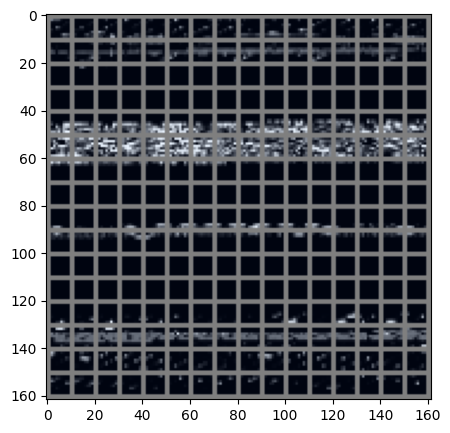

In [24]:
patches = extract_patches(test_images, patch_size = patch_size)

patches_square = patches.reshape(test_images.shape[0], -1, 3, patch_size, patch_size)

grid_size = test_images.shape[2] // patch_size
print("Sequence Length: %d" % (grid_size ** 2))

plt.figure(figsize =(5, 5))
out = torchvision.utils.make_grid(patches_square[0], grid_size, normalize = True, pad_value = 0.5)
plt.imshow(out.numpy().transpose((1, 2, 0)))

### The base transformer used for ViT

In [25]:
class TransformerBlock(nn.Module):
  def __init__(self, hidden_size = 128, num_heads = 4) -> None:
    super(TransformerBlock, self).__init__()

    self.norm1 = nn.LayerNorm(hidden_size)

    self.multihead_attn = nn.MultiheadAttention(hidden_size, num_heads = num_heads,
                                                batch_first = True, dropout = 0.1)
    self.norm2 = nn.LayerNorm(hidden_size)

    self.mlp = nn.Sequential(
        nn.Linear(hidden_size, hidden_size * 2),
        nn.LayerNorm(hidden_size * 2),
        nn.ELU(),
        nn.Linear(hidden_size * 2, hidden_size)
    )

  def forward(self, x):
    norm_x = self.norm1(x)

    x = self.multihead_attn(norm_x, norm_x, norm_x)[0] + x

    norm_x = self.norm2(x)

    x = self.mlp(norm_x) + x

    return x

### The ViT classifier

In [26]:
class ViT(nn.Module):
  def __init__(self, image_size, channels_in, patch_size, hidden_size, num_layers, num_heads = 8) -> None:
    super(ViT, self).__init__()

    self.patch_size = patch_size

    self.fc_in = nn.Linear(channels_in * patch_size * patch_size, hidden_size)

    self.blocks = nn.ModuleList([
        TransformerBlock(hidden_size, num_heads) for _ in range(num_layers)
    ])

    self.fc_out = nn.Linear(hidden_size, 10)

    self.out_vec = nn.Parameter(torch.zeros(1, 1, hidden_size))

    seq_length = (image_size // patch_size) ** 2
    self.pos_embedding = nn.Parameter(torch.empty(1, seq_length, hidden_size).normal_(std = 0.001))

  def forward(self, image):
    bs = image.shape[0]

    patch_seq = extract_patches(image, patch_size = self.patch_size)
    patch_emb = self.fc_in(patch_seq)

    patch_emb = patch_emb + self.pos_embedding

    embs = torch.cat((self.out_vec.expand(bs, 1, -1), patch_emb), 1)

    for block in self.blocks:
      embs = block(embs)

    return self.fc_out(embs[:, 0])


In [27]:
dataiter = next(iter(train_loader))

train_images , train_labels = dataiter

### Instantiating the model

In [29]:
model = ViT(image_size = test_images.shape[2],
            channels_in = test_images.shape[1],
            patch_size = patch_size,
            hidden_size = 128,
            num_layers = 8,
            num_heads = 8)

model

ViT(
  (fc_in): Linear(in_features=192, out_features=128, bias=True)
  (blocks): ModuleList(
    (0-7): 8 x TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (multihead_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (2): ELU(alpha=1.0)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
    )
  )
  (fc_out): Linear(in_features=128, out_features=10, bias=True)
)

In [30]:
num_model_params = 0

for param in model.parameters():
  num_model_params += param.flatten().shape[0]

print("This model %d (approx %d million) params!" % (num_model_params, num_model_params // 1e6))

This model 1122826 (approx 1 million) params!


In [31]:
model.to(device) # Move the model to the specified device
out = model(test_images.to(device))
out.shape

torch.Size([16, 10])

In [32]:
# Pass our network parameters to the optimiser set our lr as the learning_rate
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                    T_max=num_epochs,
                                                    eta_min=0)

In [33]:
# Define a Cross Entropy Loss
loss_fun = nn.CrossEntropyLoss()

In [34]:
## Define the training process
# This function should perform a single training epoch using our training data
def train(model, optimizer, loader, device, loss_fun, loss_logger):

    # Set Network in train mode
    model.train()
    for i, (x, y) in enumerate(tqdm(loader, leave=False, desc="Training")):
        # Forward pass of image through network and get output
        fx = model(x.to(device))

        # Calculate loss using loss function
        loss = loss_fun(fx, y.to(device))

        # Zero Gradents
        optimizer.zero_grad()
        # Backpropagate Gradents
        loss.backward()
        # Do a single optimization step
        optimizer.step()

        # Log the loss for plotting
        loss_logger.append(loss.item())

    # Return the avaerage loss and acc from the epoch as well as the logger array
    return model, optimizer, loss_logger

In [35]:
## Define the testing process
# This function should perform a single evaluation epoch, it WILL NOT be used to train our model
def evaluate(model, device, loader):

    # Initialise counter
    epoch_acc = 0

    # Set network in evaluation mode
    # Layers like Dropout will be disabled
    # Layers like Batchnorm will stop calculating running mean and standard deviation
    # and use current stored values (More on these layer types soon!)
    model.eval()

    with torch.no_grad():
        for i, (x, y) in enumerate(tqdm(loader, leave=False, desc="Evaluating")):
            # Forward pass of image through network
            fx = model(x.to(device))

            # Log the cumulative sum of the acc
            epoch_acc += (fx.argmax(1) == y.to(device)).sum().item()

    # Return the accuracy from the epoch
    return epoch_acc / len(loader.dataset)


In [36]:
## The training process
training_loss_logger = []
validation_acc_logger = []
training_acc_logger = []


### The training process

In [37]:
valid_acc = 0
train_acc = 0


# This cell implements our training loop
pbar = trange(0, num_epochs, leave=False, desc="Epoch")
for epoch in pbar:
    pbar.set_postfix_str('Accuracy: Train %.2f%%, Val %.2f%%' % (train_acc * 100, valid_acc * 100))

    # Call the training function and pass training dataloader etc
    model, optimizer, training_loss_logger = train(model=model,
                                                   optimizer=optimizer,
                                                   loader=train_loader,
                                                   device=device,
                                                   loss_fun=loss_fun,
                                                   loss_logger=training_loss_logger)

    # Call the evaluate function and pass the dataloader for both validation and training
    train_acc = evaluate(model=model, device=device, loader=train_loader)
    valid_acc = evaluate(model=model, device=device, loader=valid_loader)

    # Log the train and validation accuracies
    validation_acc_logger.append(valid_acc)
    training_acc_logger.append(train_acc)

    # Reduce learning rate
    lr_scheduler.step()

print("Training Complete")


Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/49 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/49 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Training:   0%|          | 0/49 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Training:   0%|          | 0/49 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/49 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Training Complete


### Plotting accuracy and loss

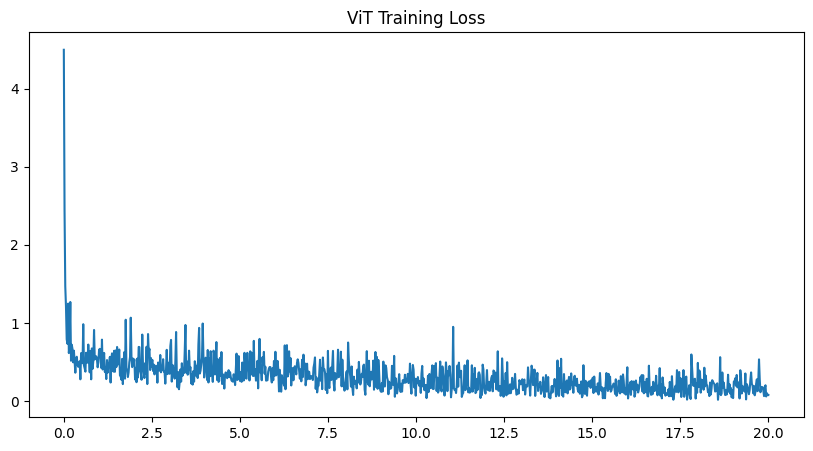

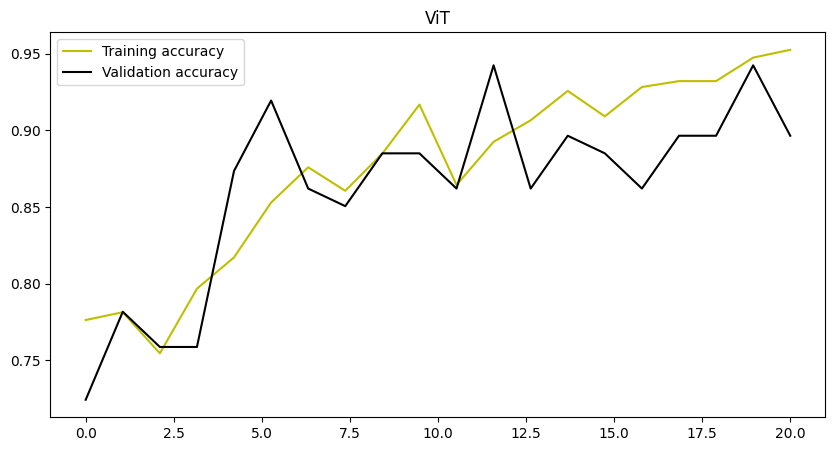

In [38]:

plt.figure(figsize = (10,5))
train_x = np.linspace(0, num_epochs, len(training_loss_logger))
plt.plot(train_x, training_loss_logger)
_ = plt.title("ViT Training Loss")
plt.figure(figsize = (10,5))
train_x = np.linspace(0, num_epochs, len(training_acc_logger))
plt.plot(train_x, training_acc_logger, c = "y")
valid_x = np.linspace(0, num_epochs, len(validation_acc_logger))
plt.plot(valid_x, validation_acc_logger, c = "k")

plt.title("ViT")
_ = plt.legend(["Training accuracy", "Validation accuracy"])

In [39]:
# Evaluate
# Call the evaluate function and pass the evaluation/test dataloader etc
test_acc = evaluate(model=model, device=device, loader=test_loader)
print("The total test accuracy is: %.2f%%" %(test_acc*100))


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

The total test accuracy is: 95.88%
